# Selección de grillas con buena probabilidad para granjas solares

In [141]:
import os
import functions
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
import rasterio

from rasterio.features import shapes
from shapely.geometry import shape, mapping

import seaborn as sns
import matplotlib.pyplot as plt

import pickle
import shutil

%load_ext autoreload

from skgstat import Variogram

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Preparation of Georeferenced Panel Data

In [142]:
geoinfo = '/Users/Daniel/Library/CloudStorage/GoogleDrive-dwiesner@metodosmixtos.com/Shared drives/Data Science/geoinfo'
data_folder = 'data'
gdrive_path = '/Users/Daniel/Library/CloudStorage/GoogleDrive-dwiesner@metodosmixtos.com/Shared drives/Projectos Activos'
full_panel_path = os.path.join(gdrive_path, 'paneles-solares/fuentes/datos/Panel-VF-panel_final.gpkg')
gdf = gpd.read_file(full_panel_path)

In [129]:
#Ubicación de granjas solares
geojson_path = os.path.join(
    geoinfo,
    "Colombia/Energia_electrica/Colombia-Energia_electrica-Proyectos de generación (XM).geojson"
)

print(geojson_path)

gdf_granjas = gpd.read_file(geojson_path)
print(gdf_granjas.shape)
gdf_granjas.head()

/Users/Daniel/Library/CloudStorage/GoogleDrive-dwiesner@metodosmixtos.com/Shared drives/Data Science/geoinfo/Colombia/Energia_electrica/Colombia-Energia_electrica-Proyectos de generación (XM).geojson
(232, 19)


,departamento_oficial,cod_mpio,municipio_oficial,codigo_sic,nombre_recurso,estado_recurso,clasificacion,tipo_generacion,tipo_despacho,combustible_defecto,capacidad_efectiva_neta_mw,factor_conversion,es_menor,agente_representante,fecha_operacion,anio_fpo,fecha,id,geometry
0,ANTIOQUIA,05380,LA ESTRELLA,3F5L,AUTOG CI JEANS,PRUEBAS,AUTOGENERADOR,Solar,ND,RAD SOLAR,1,"0,00",NO,ERCO GENERACION S.A.S. ESP,24/8/2023,2023,13/1/2026,39,POINT (-75.64886 6.13761)
1,ANTIOQUIA,05001,MEDELLÍN,3HG9,COMUNIDAD EL SALVADOR II,OPERACIÓN,GEN. DISTRIBUIDA,Solar,ND,RAD SOLAR,0,"0,00",SI,ERCO GENERACION S.A.S. ESP,23/3/2023,2023,13/1/2026,43,POINT (-75.61104 6.25759)
2,ANTIOQUIA,05001,MEDELLÍN,3HG7,COMUNIDAD EL SALVADOR I,OPERACIÓN,GEN. DISTRIBUIDA,Solar,ND,RAD SOLAR,0,"0,00",SI,ERCO GENERACION S.A.S. ESP,23/3/2023,2023,13/1/2026,44,POINT (-75.61104 6.25759)
3,ANTIOQUIA,05615,RIONEGRO,3F5N,AUTOG PINTUCO,PRUEBAS,AUTOGENERADOR,Solar,ND,RAD SOLAR,1,"0,00",NO,ERCO GENERACION S.A.S. ESP,24/8/2023,2023,13/1/2026,55,POINT (-75.41076 6.1508)
4,ANTIOQUIA,05887,YARUMAL,5IMB,AGPE CEDILLANOS,OPERACIÓN,AUTOG PEQ. ESCALA,Solar,ND,RAD SOLAR,1,"0,00",SI,UNERGY ENERGY DIGITAL S.A.S E.S.P,24/12/2025,2025,13/1/2026,81,POINT (-75.47947 6.93315)


In [143]:
#Ubicación de subestaciones
geojson_path = os.path.join(
    geoinfo,
    "Colombia/Energia_electrica/Colombia-Energia_electrica-Subestaciones.geojson"
)

print(geojson_path)

gdf_sest = gpd.read_file(geojson_path)
print(gdf_sest.shape)
gdf_sest.head()

/Users/Daniel/Library/CloudStorage/GoogleDrive-dwiesner@metodosmixtos.com/Shared drives/Data Science/geoinfo/Colombia/Energia_electrica/Colombia-Energia_electrica-Subestaciones.geojson
(499, 30)


,OBJECTID,cod_dpto,departamento,cod_mpio,municipio,id_organizacion,nombre_organizacion,nombre_ejecutor,nombre_propietario,vigencia,...,tipo_instrumento_manejo,este,norte,observacion,fecha_recepcion,created_user,created_date,last_edited_user,last_edited_date,geometry
0,1,54,NORTE DE SANTANDER,54498,OCAÑA,860016610-3,INTERCONEXIÓN ELÉCTRICA S.A E.S.P.,NA,INTERCONEXIÓN ELÉCTRICA S.A E.S.P.,31/12/2017,...,Licencia ambiental,"1.083.374,05","1.400.654,59",Sin información,,,,,,POINT (-73.32085 8.21842)
1,2,54,NORTE DE SANTANDER,54498,OCAÑA,860016610-3,INTERCONEXIÓN ELÉCTRICA S.A E.S.P.,INTERCONEXIÓN ELÉCTRICA S.A E.S.P.,INTERCONEXIÓN ELÉCTRICA S.A E.S.P.,31/12/2017,...,Licencia ambiental,"1.083.493,33","1.400.564,06",Sin información,,,,,,POINT (-73.31977 8.2176)
2,3,19,CAUCA,19300,GUACHENÉ,860016610-3,INTERCONEXIÓN ELÉCTRICA S.A E.S.P.,NA,INTERCONEXIÓN ELÉCTRICA S.A E.S.P.,31/12/2017,...,Licencia ambiental,"741.971,98","844.121,64",Sin información,,,,,,POINT (-76.39834 3.18392)
3,4,52,NARIÑO,52356,IPIALES,860016610-3,INTERCONEXIÓN ELÉCTRICA S.A E.S.P.,NA,INTERCONEXIÓN ELÉCTRICA S.A E.S.P.,31/12/2017,...,Licencia ambiental,"605.620,86","583.704,30",Sin información,,,,,,POINT (-77.61837 0.82985)
4,5,05,ANTIOQUIA,05040,ANORÍ,860016610-3,INTERCONEXIÓN ELÉCTRICA S.A E.S.P.,INTERCONEXIÓN ELÉCTRICA S.A E.S.P.,INTERCONEXIÓN ELÉCTRICA S.A E.S.P.,31/12/2017,...,Licencia ambiental,"886.840,58","1.264.132,08",Sin información,,,,,,POINT (-75.10153 6.98357)


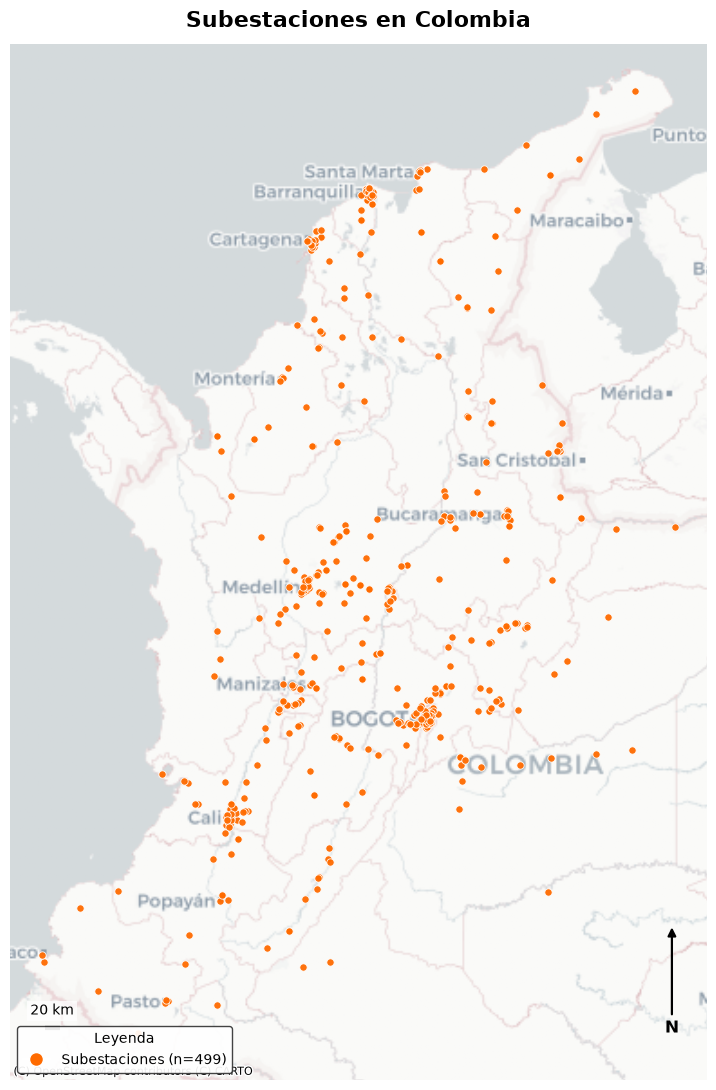

In [193]:
import matplotlib.pyplot as plt
import contextily as ctx
from matplotlib.lines import Line2D

# Copy and ensure CRS
gdf_map = gdf_sest.copy()
if gdf_map.crs is None:
    gdf_map = gdf_map.set_crs("EPSG:4326")

# Web Mercator for basemap
gdf_map = gdf_map.to_crs(epsg=3857)

def add_scalebar(ax, length_km=20, pad=0.05):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    length_m = length_km * 1000

    # Bottom-left placement
    xb = x0 + (x1 - x0) * pad
    yb = y0 + (y1 - y0) * pad

    ax.plot([xb, xb + length_m], [yb, yb], color="black", linewidth=3, solid_capstyle="butt")
    ax.text(
        xb + length_m / 2,
        yb + (y1 - y0) * 0.01,
        f"{length_km} km",
        ha="center",
        va="bottom",
        fontsize=10,
        color="black",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=2),
    )

fig, ax = plt.subplots(figsize=(11, 11))

# Substations layer
gdf_map.plot(
    ax=ax,
    markersize=28,
    color="#ff6b00",
    edgecolor="white",
    linewidth=0.6,
    alpha=0.95,
)

# Basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    attribution_size=8,
)

# Title and cosmetics
ax.set_title("Subestaciones en Colombia", fontsize=16, weight="bold", pad=12)
ax.set_axis_off()

# Legend
legend_elements = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label=f"Subestaciones (n={len(gdf_map):,})",
        markerfacecolor="#ff6b00",
        markeredgecolor="white",
        markersize=10
    )
]
ax.legend(
    handles=legend_elements,
    loc="lower left",
    frameon=True,
    framealpha=0.92,
    facecolor="white",
    edgecolor="#333333",
    title="Leyenda"
)

# North arrow
ax.annotate(
    "N",
    xy=(0.95, 0.15),
    xytext=(0.95, 0.05),
    xycoords="axes fraction",
    textcoords="axes fraction",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold",
    arrowprops=dict(arrowstyle="-|>", color="black", lw=1.6),
)

# Scale bar
add_scalebar(ax, length_km=20)

plt.tight_layout()
plt.show()

## Selection and Preparation of Geospatial Covariate Layers

### Dealing with missing values

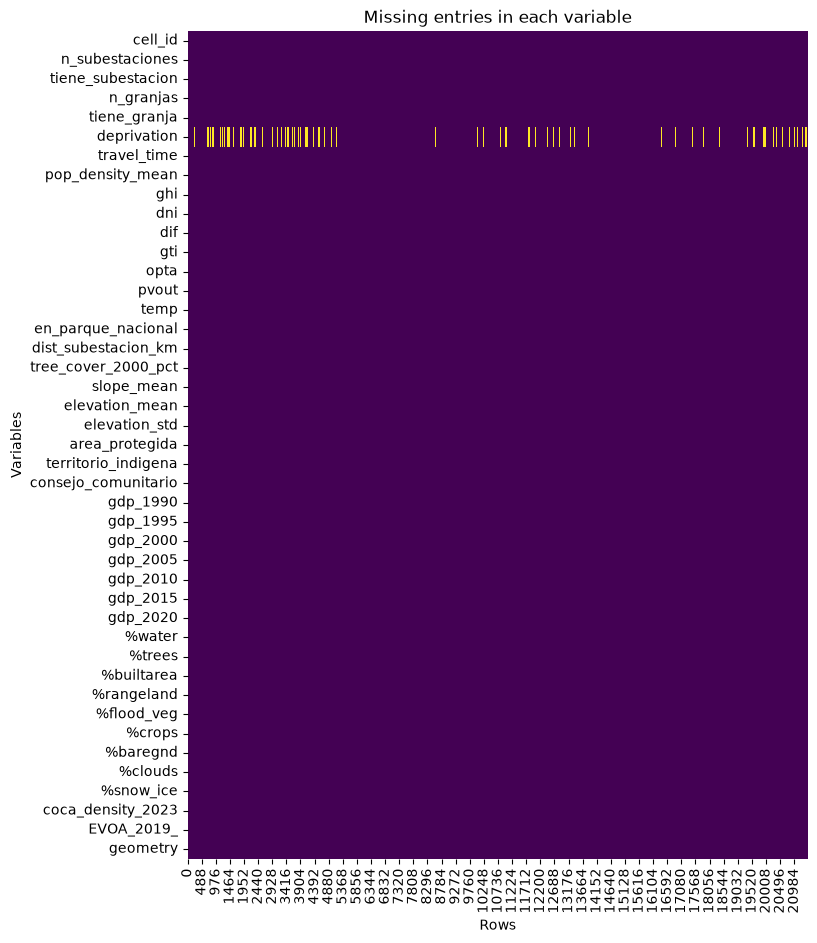

In [146]:
functions.plot_missing_values_vertical(gdf)

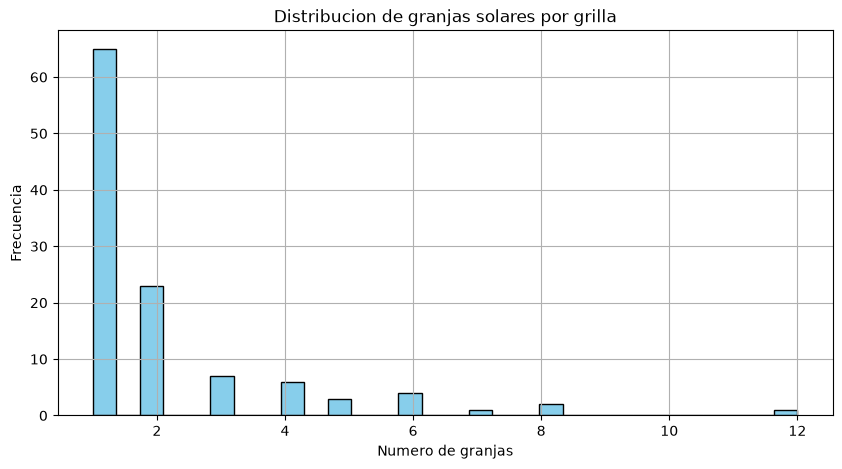

In [148]:
ax = gdf[gdf['n_granjas'] > 0]['n_granjas'].hist(
    bins=30, figsize=(10, 5), color='skyblue', edgecolor='black'
)
ax.set_title('Distribucion de granjas solares por grilla')
ax.set_xlabel('Numero de granjas')
ax.set_ylabel('Frecuencia')
plt.show()

In [149]:
#We perform simple interpolation of null values to keep going, but the input data should not have any. 
for column in columns_with_nulls: 
    # Perform IDW interpolation to replace null values
    gdf = functions.idw_interpolation(gdf, column)
    #gdf[column] = gdf[column].fillna(0)

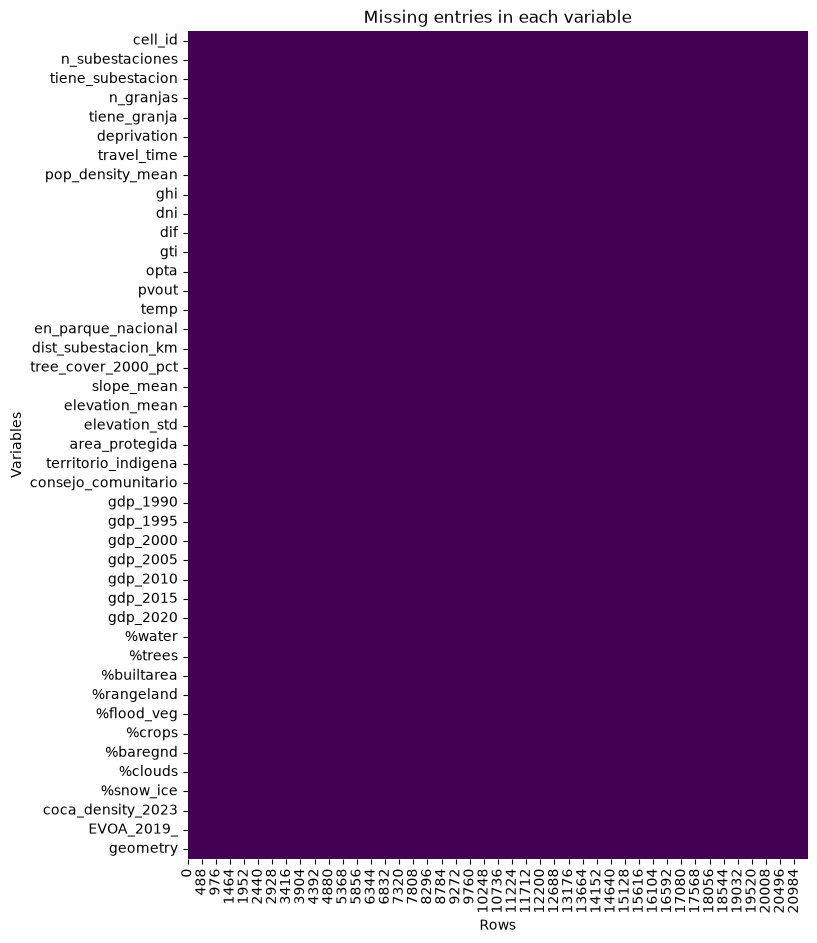

In [150]:
functions.plot_missing_values_vertical(gdf)

### Selecting only grids within range of substations

In [157]:
#Using a metric CRS for distance calculations

metric_crs = "EPSG:32618"
gdf_granjas = gdf_granjas.to_crs(metric_crs)
gdf_sest = gdf_sest.to_crs(metric_crs)

In [162]:

# 3) Distance from each farm to the nearest substation
subs_union = gdf_sest.geometry.union_all()   # shapely 2 / recent geopandas
dist_m = gdf_granjas.geometry.distance(subs_union)

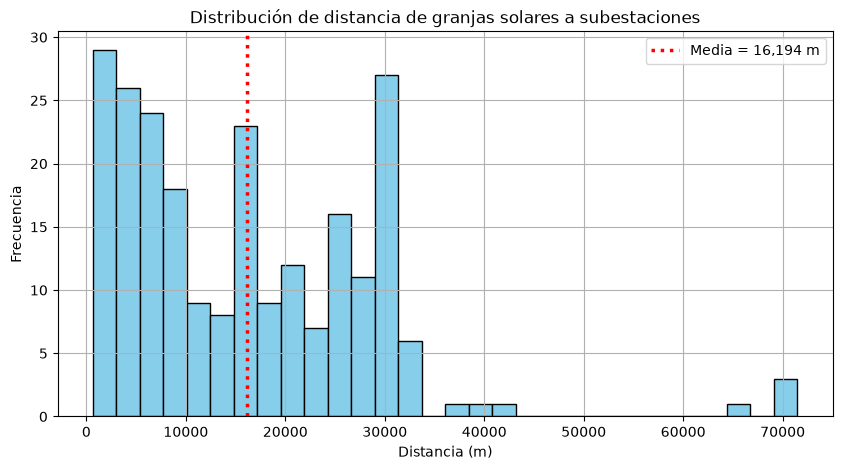

In [209]:
mean_dist_m = dist_m.mean()

ax = dist_m.hist(bins=30, figsize=(10, 5), color='skyblue', edgecolor='black')

ax.axvline(
mean_dist_m,
color='red',
linestyle=':',
linewidth=2.5,
label=f"Media = {mean_dist_m:,.0f} m"
)

ax.set_title('Distribución de distancia de granjas solares a subestaciones')
ax.set_xlabel('Distancia (m)')
ax.set_ylabel('Frecuencia')
ax.legend()

In [166]:
# 4) ean of those distances
mean_dist_m = dist_m.mean()

print(f"Mean distance to a substation is: {mean_dist_m:,.0f} m)")

Mean distance to a substation is: 16,194 m)


In [206]:
#Reduce the sample to the grids that intersect a 10k buffer arund the subestations. This is to avoid the model to learn from grids that are too far away from the substations, which are not relevant for the analysis.

# 1) Create mean_distance buffer
gdf_sest_buffer = gdf_sest.copy()
gdf_sest_buffer["geometry"] = gdf_sest.geometry.buffer(mean_dist_m)
gdf_sest_buffer.to_file(os.path.join(gdrive_path, 'paneles-solares/outputs/substations_buffer.gpkg'), index=False)

In [212]:
#Intersecting the panel to Identify the grids that are within the buffer the substations

# Keep only grids that intersect at least one 10 km substation buffer
# Fast approach: one merged geometry from all buffers
buffer_union = gdf_sest_buffer.geometry.union_all()

gdf = gdf.to_crs(metric_crs)
gdf_filtered = gdf[gdf.geometry.intersects(buffer_union)].copy()
gdf_filtered.to_file
gdf_filtered.to_file(os.path.join(gdrive_path, 'paneles-solares/outputs/grids_within_buffer.gpkg'), index=False)

print("Original grids:", len(gdf))
print("Grids within buffer of any substation:", len(gdf_filtered))

Original grids: 21447
Grids within buffer of any substation: 7239


In [204]:
gdf_filtered.groupby('tiene_granja').describe()

n_subestaciones                                               \
                       count      mean       std  min  25%  50%  75%  max   
tiene_granja                                                                
0                     7168.0  0.064314  0.349480  0.0  0.0  0.0  0.0  5.0   
1                       71.0  0.338028  0.909374  0.0  0.0  0.0  0.0  4.0   

             tiene_subestacion            ... coca_density_2023             \
                         count      mean  ...               75%        max   
tiene_granja                              ...                                
0                       7168.0  0.042690  ...               0.0  54.241673   
1                         71.0  0.169014  ...               0.0   0.000000   

             EVOA_2019_                                                    \
                  count      mean       std       min       25%       50%   
tiene_granja                                                                
0                7168.0  4.475633  1.023372  0.117081  4.456003  4.456003   
1                  71.0  4.456003  0.000000  4.456003  4.456003  4.456003   

                                   
                   75%        max  
tiene_granja                       
0             4.456003  81.504616  
1             4.456003   4.456003  

[2 rows x 320 columns]

In [213]:
gdf_filtered = gdf_filtered[gdf_filtered['tiene_granja']==0] #Solo las grillas que no tienen granjas solares, para que el modelo aprenda a predecir la probabilidad de tener una granja solar en el futuro.

# Similarity Score

- Use group 1 as the positive profile.
- Score each grid in group 2 by feature similarity to group 1.
- Rank group 2 by that score (highest = most similar, more likely candidates).
- Use this recipe with Mahalanobis-like profile similarity plus nearest-neighbor similarity:



In [224]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.covariance import LedoitWolf
from sklearn.neighbors import NearestNeighbors

### Inputs

In [225]:
# gdf_group1: grids that contain solar farms (positives)
# gdf_group2: grids close to substations (candidates)
# id_col: unique grid id column
id_col = "cell_id"   # or "grid_id", adjust to your data

#All grids that contain a solar farm. 
gdf1 = gdf[gdf['n_granjas'] > 0].copy()
#All grids within mean distance of a substation without solar farms.
gdf2 = gdf_filtered[gdf_filtered['tiene_granja']==0]

gdf_group1 = gdf1.copy()
gdf_group2 = gdf2.copy()

### 1) Select predictor columns

In [226]:
exclude_cols = {
    "geometry", id_col,
    "tiene_granja", "n_granjas",  # prevent leakage from known labels/targets
    "gdp_1990", "gdp_1995", "gdp_2000", "gdp_2005", "gdp_2010", "gdp_2015",  # exclude but latest GDP column
}
feature_cols = [
    c for c in gdf_group1.columns
    if c in gdf_group2.columns
    and c not in exclude_cols
    and pd.api.types.is_numeric_dtype(gdf_group1[c])
]

X1 = gdf_group1[feature_cols].replace([np.inf, -np.inf], np.nan)
X2 = gdf_group2[feature_cols].replace([np.inf, -np.inf], np.nan)

# -----------------------------
# 2) Impute + scale
# -----------------------------
imp = SimpleImputer(strategy="median")
scaler = RobustScaler()

X1s = scaler.fit_transform(imp.fit_transform(X1))
X2s = scaler.transform(imp.transform(X2))

# -----------------------------
# 3) Similarity score A: distance to positive profile
#    (LedoitWolf covariance is stable with many correlated covariates)
# -----------------------------
mu = X1s.mean(axis=0)
cov = LedoitWolf().fit(X1s)
VI = cov.precision_

delta = X2s - mu
d2 = np.einsum("ij,jk,ik->i", delta, VI, delta)   # squared Mahalanobis distance
score_profile = 1.0 / (1.0 + d2)                  # higher is more similar

# -----------------------------
# 4) Similarity score B: closeness to nearest positive grids
# -----------------------------
k = min(5, len(X1s))
nn = NearestNeighbors(n_neighbors=k, metric="euclidean")
nn.fit(X1s)
dist_knn, _ = nn.kneighbors(X2s)
mean_knn_dist = dist_knn.mean(axis=1)
score_knn = 1.0 / (1.0 + mean_knn_dist)

# -----------------------------
# 5) Combine and rank
# -----------------------------
mm = MinMaxScaler()
s1 = mm.fit_transform(score_profile.reshape(-1, 1)).ravel()
s2 = mm.fit_transform(score_knn.reshape(-1, 1)).ravel()

combined_score = 0.6 * s1 + 0.4 * s2  # tune weights if needed

gdf_ranked = gdf_group2.copy()
gdf_ranked["sim_profile"] = s1
gdf_ranked["sim_knn"] = s2
gdf_ranked["sim_score"] = combined_score
gdf_ranked = gdf_ranked.sort_values("sim_score", ascending=False)

# Top candidate grids
top_n = 100
top_candidates = gdf_ranked.head(top_n)

print("Candidates scored:", len(gdf_ranked))
print(top_candidates[[id_col, "sim_score", "sim_profile", "sim_knn"]].head(10))

Candidates scored: 7168
       cell_id  sim_score  sim_profile   sim_knn
10062  0014085   0.841508     0.933700  0.703219
6527   0009399   0.841029     1.000000  0.602573
4664   0007111   0.824906     0.914554  0.690433
15855  0021783   0.816019     0.855776  0.756383
7990   0011232   0.812922     0.907662  0.670813
7959   0011201   0.812135     0.799356  0.831303
7960   0011202   0.809882     0.828136  0.782501
4836   0007314   0.807546     0.892661  0.679872
6151   0008889   0.806528     0.809589  0.801935
8410   0011829   0.806249     0.894154  0.674390


In [227]:
gdrive_output_path = os.path.join(gdrive_path, 'paneles-solares/outputs/top_candidates.gpkg')

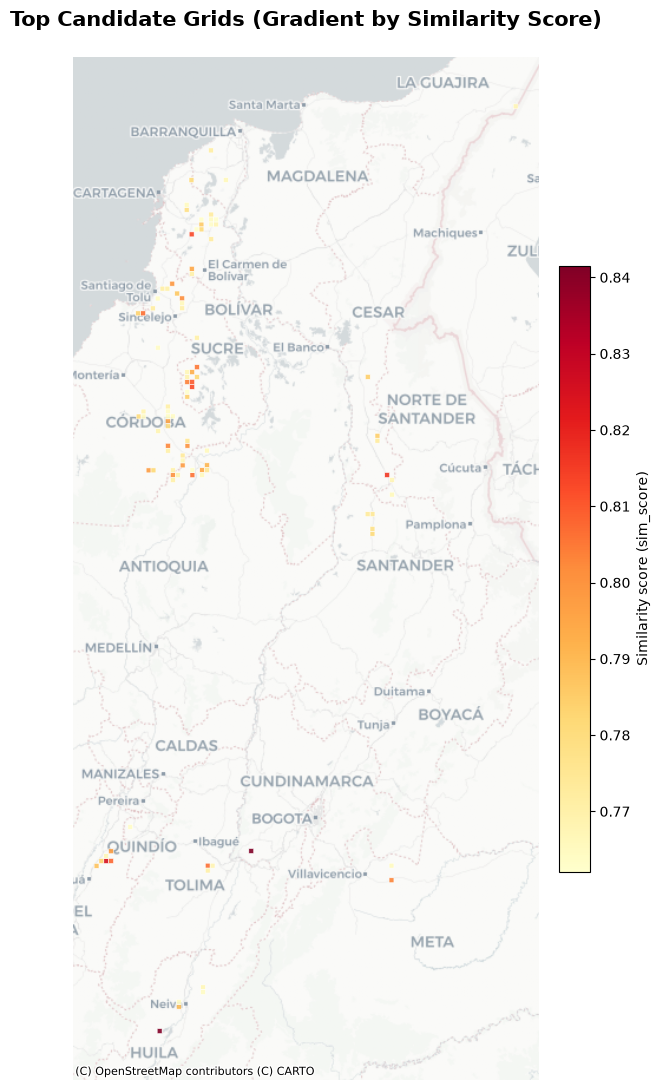

In [228]:
import matplotlib.pyplot as plt
import contextily as ctx
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# Optional: include substations for context
show_substations = False

# --- Prepare layers ---
gdf_top = top_candidates.copy()
gdf_sub = gdf_sest.copy()

# Ensure both are in the same projected CRS for web basemap
if gdf_top.crs is None:
    raise ValueError("top_candidates has no CRS.")
if show_substations and gdf_sub.crs is None:
    raise ValueError("gdf_sest has no CRS.")

gdf_top_3857 = gdf_top.to_crs(epsg=3857)
if show_substations:
    gdf_sub_3857 = gdf_sub.to_crs(epsg=3857)

# --- Validate score column ---
score_col = "sim_score"
if score_col not in gdf_top_3857.columns:
    raise ValueError(f"Column '{score_col}' not found in top_candidates.")

# --- Plot ---
fig, ax = plt.subplots(figsize=(11, 11))

# Plot top candidates with gradient color scale
vmin = float(gdf_top_3857[score_col].min())
vmax = float(gdf_top_3857[score_col].max())
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = "YlOrRd"  # yellow -> red

gdf_top_3857.plot(
    ax=ax,
    column=score_col,
    cmap=cmap,
    markersize=40,
    alpha=0.9,
    edgecolor="white",
    linewidth=0.4,
    legend=False
)

# Optional: overlay substations
if show_substations:
    gdf_sub_3857.plot(
        ax=ax,
        color="#2b8cbe",
        markersize=16,
        alpha=0.8,
        edgecolor="white",
        linewidth=0.3
    )

# Basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    attribution_size=8
)

# Colorbar (gradient legend)
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Similarity score (sim_score)", fontsize=10)

# Title and style
ax.set_title("Top Candidate Grids (Gradient by Similarity Score)", fontsize=15, weight="bold", pad=12)
ax.set_axis_off()

plt.tight_layout()
plt.show()

In [229]:
top_candidates.to_file(gdrive_output_path, index=False)